# Analyzer

The strategy is simple.

We want to be invested proportionally to the confidence score and in the direction of the signal.

In [15]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('exports/contrarian_signals_20251227_170332.csv')

# Filter for BTC, ETH, and SOL only
df_filtered = df[df['coin'].isin(['BTC', 'ETH', 'SOL'])].copy()

# Sort by coin and timestamp
df_filtered = df_filtered.sort_values(['coin', 'timestamp']).reset_index(drop=True)

print(f"Total signals: {len(df_filtered)}")
print(f"\nSignals per coin:")
print(df_filtered['coin'].value_counts())

Total signals: 1524

Signals per coin:
coin
BTC    508
ETH    508
SOL    508
Name: count, dtype: int64


In [16]:
# Calculate price change (return) for each period
# Group by coin and calculate the NEXT price (not previous)
df_filtered['next_price'] = df_filtered.groupby('coin')['current_price'].shift(-1)

# Calculate return: (next_price - current_price) / current_price
df_filtered['price_return'] = (df_filtered['next_price'] - df_filtered['current_price']) / df_filtered['current_price']

# Drop rows with NaN returns (last row of each coin)
df_filtered = df_filtered.dropna(subset=['price_return']).reset_index(drop=True)

print(f"Signals after removing NaN returns: {len(df_filtered)}")
print(f"\nSignals per coin:")
print(df_filtered['coin'].value_counts())

# Display sample
print("\nSample with returns:")
display(df_filtered[['coin', 'timestamp', 'current_price', 'next_price', 'price_return']].head(10))

Signals after removing NaN returns: 615

Signals per coin:
coin
BTC    205
ETH    205
SOL    205
Name: count, dtype: int64

Sample with returns:


,coin,timestamp,current_price,next_price,price_return
0,BTC,2025-12-23 09:08:59,87545.5,87294.5,-0.002867
1,BTC,2025-12-23 09:39:34,87294.5,87506.5,0.002429
2,BTC,2025-12-23 10:10:08,87506.5,87575.5,0.000789
3,BTC,2025-12-23 10:40:42,87575.5,87661.5,0.000982
4,BTC,2025-12-23 11:11:17,87661.5,87746.5,0.000970
5,BTC,2025-12-23 11:41:51,87746.5,87840.5,0.001071
6,BTC,2025-12-23 12:12:25,87840.5,87844.5,0.000046
7,BTC,2025-12-23 12:43:00,87844.5,87741.5,-0.001173
8,BTC,2025-12-23 13:13:34,87741.5,87653.5,-0.001003
9,BTC,2025-12-23 13:44:09,87653.5,87748.5,0.001084


In [17]:
# Calculate position size based on confidence score
# Max capacity = $100,000 divide for the 3 assets
df_filtered['position_size'] = df_filtered['confidence_score'] * 100000 / 3

# For SHORT signals, position is negative (we profit when price goes down)
# For LONG signals, position is positive (we profit when price goes up)
df_filtered['position_direction'] = df_filtered['signal_direction'].map({'LONG': 1, 'SHORT': -1})

# Calculate P&L for the period
# P&L = position_size * position_direction * price_return
df_filtered['period_pnl'] = df_filtered['position_size'] * df_filtered['position_direction'] * df_filtered['price_return']

# Display results
print("Strategy Results:")
display(df_filtered[['coin', 'timestamp', 'signal_direction', 'confidence_score', 
                      'position_size', 'price_return', 'period_pnl']].head(15))

Strategy Results:


,coin,timestamp,signal_direction,confidence_score,position_size,price_return,period_pnl
0,BTC,2025-12-23 09:08:59,SHORT,0.282,9400.000000,-0.002867,26.950557
1,BTC,2025-12-23 09:39:34,SHORT,0.254,8466.666667,0.002429,-20.561815
2,BTC,2025-12-23 10:10:08,SHORT,0.273,9100.000000,0.000789,-7.175467
3,BTC,2025-12-23 10:40:42,SHORT,0.285,9500.000000,0.000982,-9.329093
4,BTC,2025-12-23 11:11:17,SHORT,0.317,10566.666667,0.000970,-10.245851
5,BTC,2025-12-23 11:41:51,SHORT,0.314,10466.666667,0.001071,-11.212603
6,BTC,2025-12-23 12:12:25,SHORT,0.320,10666.666667,0.000046,-0.485729
7,BTC,2025-12-23 12:43:00,SHORT,0.321,10700.000000,-0.001173,12.546033
8,BTC,2025-12-23 13:13:34,SHORT,0.307,10233.333333,-0.001003,10.263482
9,BTC,2025-12-23 13:44:09,SHORT,0.290,9666.666667,0.001084,-10.476859


In [18]:
# Remove first period for each coin (no previous price to calculate return)
df_results = df_filtered.dropna(subset=['period_pnl'])

# Overall statistics
print("="*80)
print("OVERALL PERFORMANCE")
print("="*80)
print(f"Total P&L: ${df_results['period_pnl'].sum():.2f}")
print(f"Average P&L per trade: ${df_results['period_pnl'].mean():.2f}")
print(f"Win rate: {(df_results['period_pnl'] > 0).sum() / len(df_results) * 100:.2f}%")
print(f"Total trades: {len(df_results)}")

# Performance by coin
print("\n" + "="*80)
print("PERFORMANCE BY COIN")
print("="*80)
by_coin = df_results.groupby('coin').agg({
    'period_pnl': ['sum', 'mean', 'count'],
}).round(2)
display(by_coin)

# Performance by signal direction
print("\n" + "="*80)
print("PERFORMANCE BY SIGNAL DIRECTION")
print("="*80)
by_signal = df_results.groupby('signal_direction').agg({
    'period_pnl': ['sum', 'mean', 'count'],
}).round(2)
display(by_signal)

OVERALL PERFORMANCE
Total P&L: $307.36
Average P&L per trade: $0.50
Win rate: 46.18%
Total trades: 615

PERFORMANCE BY COIN


period_pnl            
            sum  mean count
coin                       
BTC      -30.07 -0.15   205
ETH      210.81  1.03   205
SOL      126.62  0.62   205


PERFORMANCE BY SIGNAL DIRECTION


period_pnl           
                        sum mean count
signal_direction                      
SHORT                307.36  0.5   615

In [19]:
# Calculate cumulative P&L by coin
df_results['cumulative_pnl'] = df_results.groupby('coin')['period_pnl'].cumsum()

# Display final cumulative P&L
print("Final Cumulative P&L by Coin:")
final_pnl = df_results.groupby('coin')['cumulative_pnl'].last()
display(final_pnl)

# Show evolution over time
print("\nCumulative P&L over time (last 10 periods per coin):")
display(df_results[['coin', 'timestamp', 'period_pnl', 'cumulative_pnl']].tail(10))

Final Cumulative P&L by Coin:


coin
BTC    -30.066427
ETH    210.809584
SOL    126.621453
Name: cumulative_pnl, dtype: float64


Cumulative P&L over time (last 10 periods per coin):


,coin,timestamp,period_pnl,cumulative_pnl
605,SOL,2025-12-27 10:49:38,-9.819647,154.093032
606,SOL,2025-12-27 11:20:13,-1.089874,153.003158
607,SOL,2025-12-27 11:50:48,2.905976,155.909134
608,SOL,2025-12-27 12:21:22,13.807877,169.717011
609,SOL,2025-12-27 12:51:57,-11.645687,158.071325
610,SOL,2025-12-27 13:22:31,-7.339599,150.731726
611,SOL,2025-12-27 13:53:06,7.333035,158.064761
612,SOL,2025-12-27 14:23:41,-15.812957,142.251804
613,SOL,2025-12-27 14:54:15,-11.168420,131.083385
614,SOL,2025-12-27 15:24:50,-4.461932,126.621453


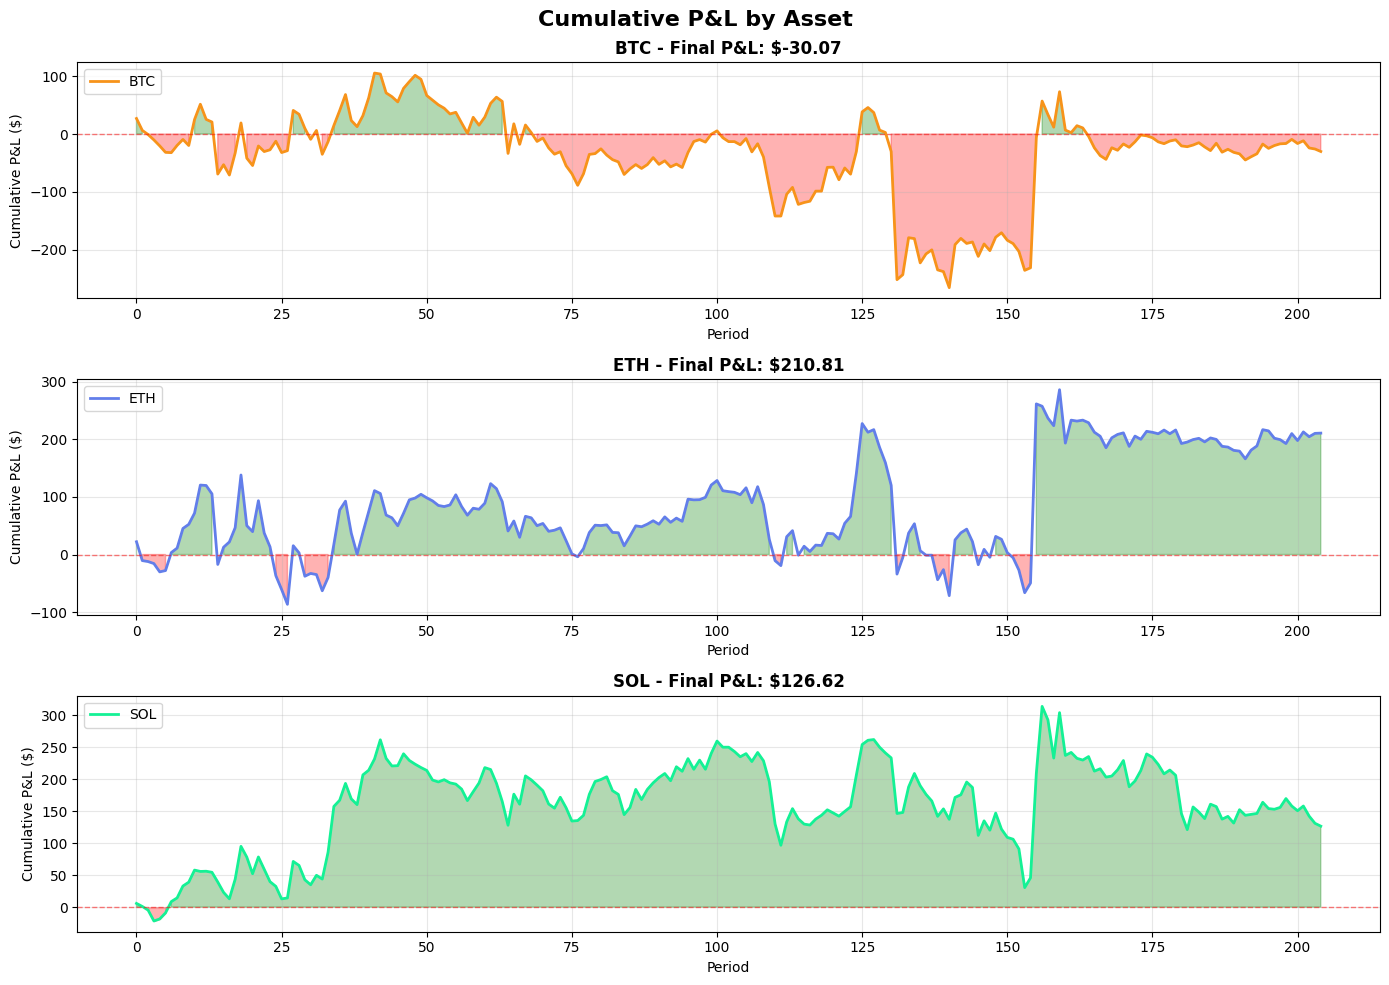

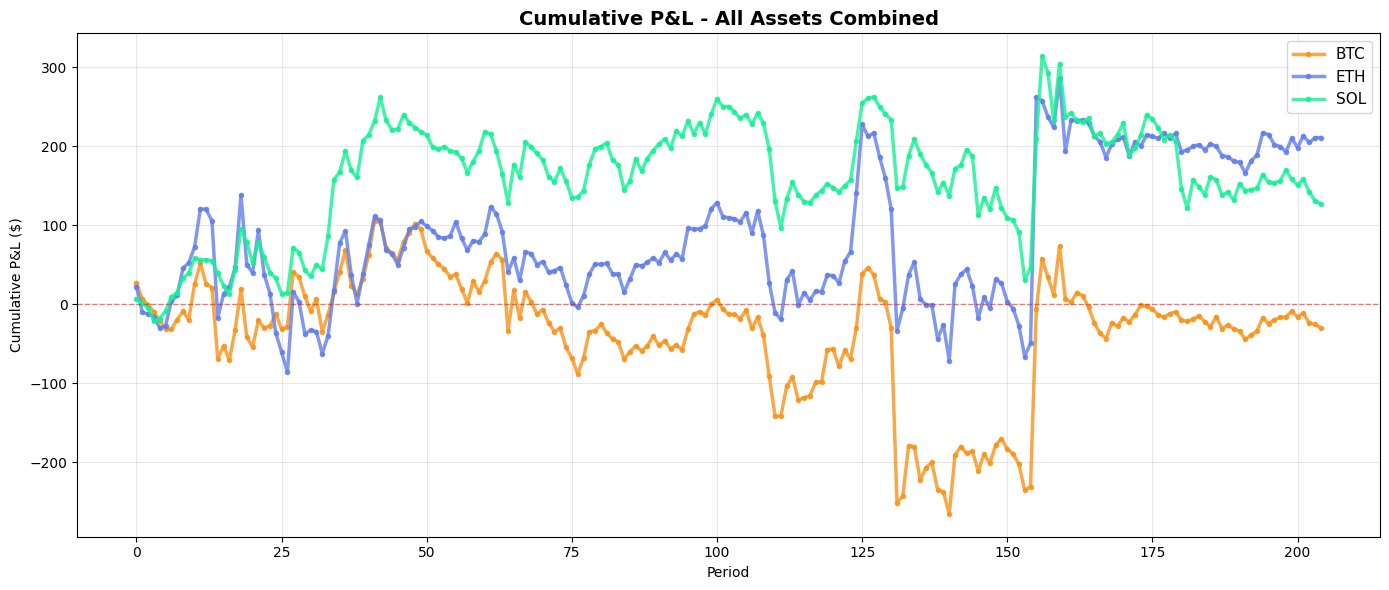

In [20]:
import matplotlib.pyplot as plt

# Create figure with subplots for each coin
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Cumulative P&L by Asset', fontsize=16, fontweight='bold')

coins = ['BTC', 'ETH', 'SOL']
colors = ['#F7931A', '#627EEA', '#14F195']  # BTC orange, ETH purple, SOL green

for idx, (coin, color) in enumerate(zip(coins, colors)):
    coin_data = df_results[df_results['coin'] == coin].copy()
    
    ax = axes[idx]
    ax.plot(range(len(coin_data)), coin_data['cumulative_pnl'], 
            color=color, linewidth=2, label=coin)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.fill_between(range(len(coin_data)), coin_data['cumulative_pnl'], 0, 
                     where=(coin_data['cumulative_pnl'] >= 0), alpha=0.3, color='green')
    ax.fill_between(range(len(coin_data)), coin_data['cumulative_pnl'], 0, 
                     where=(coin_data['cumulative_pnl'] < 0), alpha=0.3, color='red')
    
    ax.set_title(f'{coin} - Final P&L: ${coin_data["cumulative_pnl"].iloc[-1]:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Period')
    ax.set_ylabel('Cumulative P&L ($)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Combined chart
plt.figure(figsize=(14, 6))
for coin, color in zip(coins, colors):
    coin_data = df_results[df_results['coin'] == coin].copy()
    plt.plot(range(len(coin_data)), coin_data['cumulative_pnl'], 
             color=color, linewidth=2.5, label=coin, marker='o', markersize=3, alpha=0.8)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Cumulative P&L - All Assets Combined', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Cumulative P&L ($)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()